# 04 — Figures (Colombia)

1. `step3_overview.png`: every step-1/2/3 variant (area and accuracy).
2. `main_result.png`: the headline comparison — how the 87.9 % accuracy claim
   holds under stricter validation, and what the area figures mean.

All values are read from `results/*.csv`, except the paper's published numbers.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
SMOKE = os.environ.get("SMOKE", "0") == "1"
RESULTS = Path("../results/smoke" if SMOKE else "../results")
FIGURES = Path("../figures/smoke" if SMOKE else "../figures")

s1 = pd.read_csv(Path("../results") / "step1_reproduction_colombia.csv")
s2 = pd.read_csv(RESULTS / "step2_replication_colombia.csv").set_index("metric")
s3 = pd.read_csv(RESULTS / "step3_robustness_colombia.csv").set_index("variant")
opt_path = RESULTS / "step3_optional_variants_colombia.csv"  # optional rule; may be absent
if opt_path.exists():
    s3 = pd.concat([s3, pd.read_csv(opt_path).set_index("variant").drop(index="baseline_step2", errors="ignore")])
cv = pd.read_csv(RESULTS / "step3_spatial_cv.csv").set_index("scheme")
cv_e_path = RESULTS / "step3_spatial_cv_chelsa.csv"
cv_e = pd.read_csv(cv_e_path).set_index("scheme") if cv_e_path.exists() else pd.DataFrame(columns=["mean_accuracy"])


def s1v(metric: str, model: str = "ellipsoid_wgs84") -> float:
    return float(s1[(s1.metric == metric) & (s1.area_model == model)].value_mha.iloc[0])

In [2]:
area_rows = [
    ("Paper (Supp. Tables 3 / 4)", 11.19, 13.70, "paper"),
    ("Step 1: authors' map, exact area", s1v("pnr_continuous_expected"), s1v("pnr_binary_product"), "repro"),
    ("Step 1: authors' map, count x 0.09 ha", s1v("pnr_continuous_expected", "nominal_900m2"),
     s1v("pnr_binary_product", "nominal_900m2"), "repro"),
    ("Step 2: RF, uncalibrated", s2.loc["expected_area_uncalibrated_mha", "value"],
     s2.loc["area_p_gt_0.5_uncalibrated_mha", "value"], "repl"),
    ("Step 2: RF, calibrated (prior shift)", s2.loc["expected_area_prior_shift_mha", "value"],
     s2.loc["area_p_gt_0.5_prior_shift_mha", "value"], "repl"),
]
for v, lab in [("a_landcover_1992", "3a: LC 1992"), ("a_landcover_1999", "3a: LC 1999"),
               ("d_hist_gradient_boosting", "3d: gradient boosting"),
               ("c_selected_without_during_vars", "3c: selected, no NPP/fire/roads"),
               ("e_chelsa_bioclim_SENSITIVITY", "3e: CHELSA climate (sensitivity)")]:
    if v in s3.index:
        area_rows.append((f"{lab}, uncal.", s3.loc[v, "expected_uncal_mha"], s3.loc[v, "gt05_uncal_mha"], "robust"))
        area_rows.append((f"{lab}, calibrated", s3.loc[v, "expected_prior_mha"], s3.loc[v, "gt05_prior_mha"], "robust"))
areas = pd.DataFrame(area_rows, columns=["label", "expected", "gt50", "kind"])

acc_rows = [("Paper: validation", 0.879, "paper"), ("Paper: OOB", 0.878, "paper"),
            ("Paper: Neotropics OA (SI A1.3)", 0.865, "paper"),
            ("Step 2: OOB", s2.loc["oob_accuracy", "value"], "repl"),
            ("Step 2: validation (random points)", s2.loc["validation_accuracy", "value"], "repl")]
for sch in cv.index:
    acc_rows.append((f"3b: 5-fold CV, {sch}", cv.loc[sch, "mean_accuracy"], "robust"))
for sch in cv_e.index:
    acc_rows.append((f"3e (CHELSA, sensitivity): CV {sch}", cv_e.loc[sch, "mean_accuracy"], "robust"))
for v in s3.index:
    if v != "baseline_step2":
        acc_rows.append((f"3: {v}", s3.loc[v, "validation_accuracy"], "robust"))
accs = pd.DataFrame(acc_rows, columns=["label", "accuracy", "kind"])
colors = {"paper": "#444444", "repro": "#1f77b4", "repl": "#2ca02c", "robust": "#ff7f0e"}

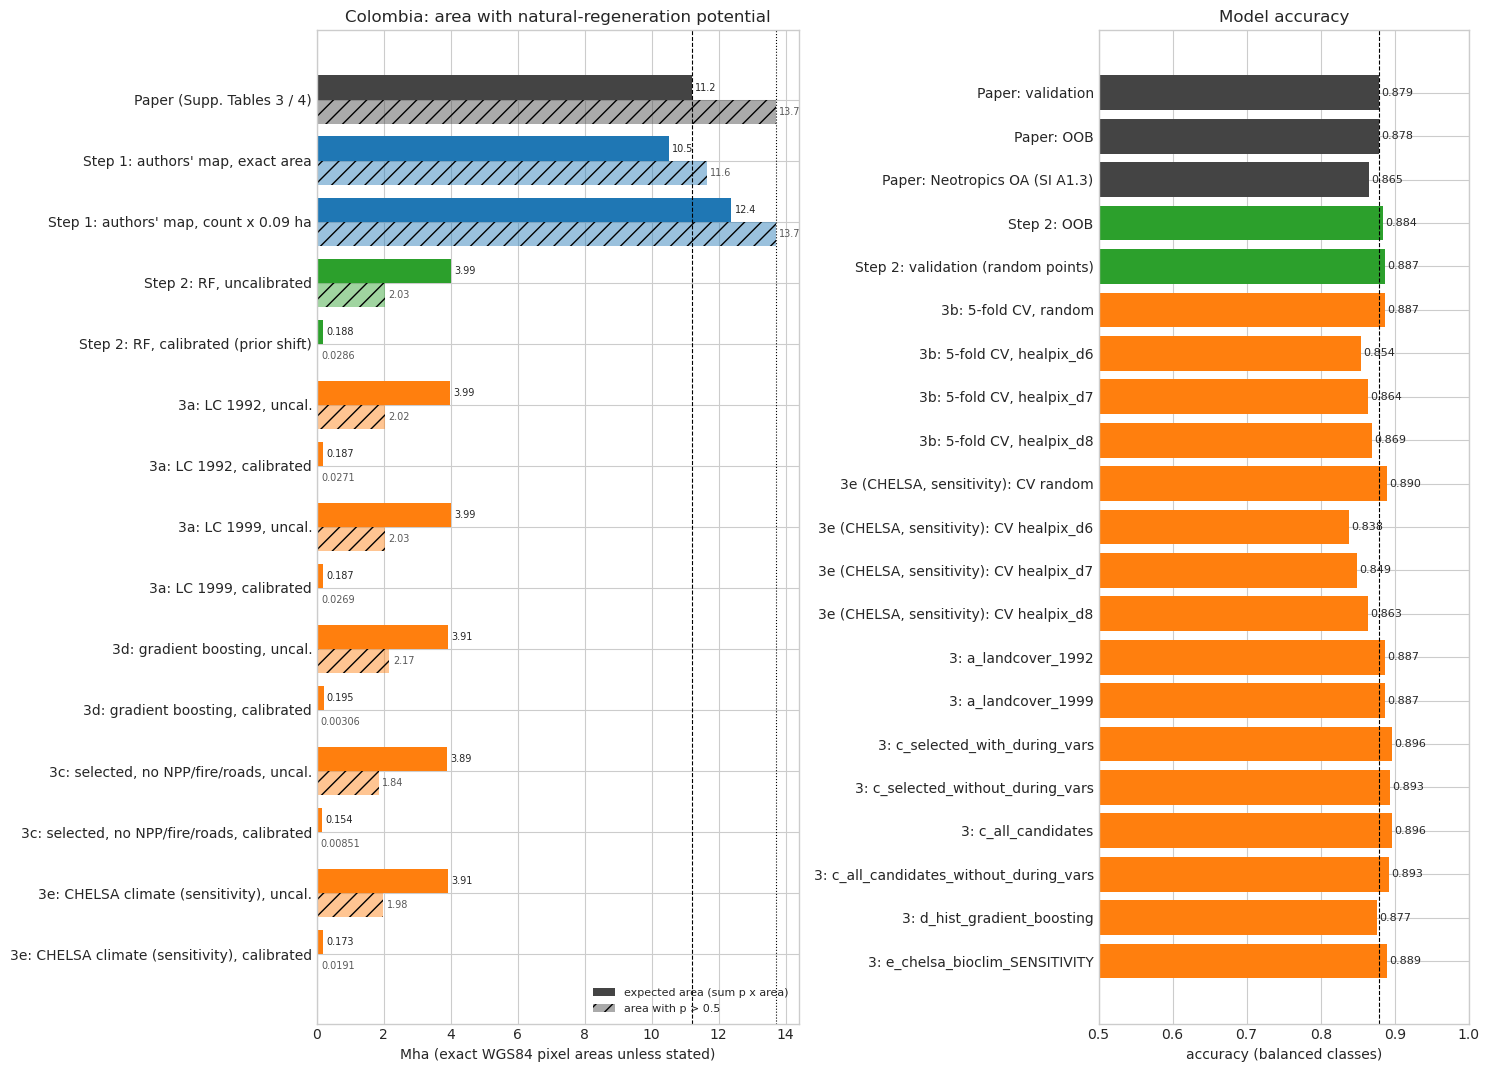

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 0.42 * max(len(areas), len(accs)) + 2),
                               gridspec_kw={"width_ratios": [1.3, 1]})
y = np.arange(len(areas))[::-1]
ax1.barh(y + 0.2, areas.expected, 0.4, color=[colors[k] for k in areas.kind], label="expected area (sum p x area)")
ax1.barh(y - 0.2, areas.gt50, 0.4, color=[colors[k] for k in areas.kind], alpha=0.45, hatch="//",
         label="area with p > 0.5")
for yy, e_, g_ in zip(y, areas.expected, areas.gt50):
    ax1.text(e_ + 0.1, yy + 0.2, f"{e_:.3g}", va="center", fontsize=7)
    ax1.text(g_ + 0.1, yy - 0.2, f"{g_:.3g}", va="center", fontsize=7, color="0.35")
ax1.set_yticks(y, areas.label)
ax1.axvline(11.19, color="k", ls="--", lw=0.8)
ax1.axvline(13.70, color="k", ls=":", lw=0.8)
ax1.set_xlabel("Mha (exact WGS84 pixel areas unless stated)")
ax1.set_title("Colombia: area with natural-regeneration potential")
ax1.legend(loc="lower right", fontsize=8)
y2 = np.arange(len(accs))[::-1]
ax2.barh(y2, accs.accuracy, color=[colors[k] for k in accs.kind])
ax2.set_yticks(y2, accs.label)
ax2.set_xlim(0.5, 1.0)
ax2.axvline(0.879, color="k", ls="--", lw=0.8)
for yy, a in zip(y2, accs.accuracy):
    ax2.text(a + 0.003, yy, f"{a:.3f}", va="center", fontsize=8)
ax2.set_xlabel("accuracy (balanced classes)")
ax2.set_title("Model accuracy")
fig.tight_layout()
fig.savefig(FIGURES / "step3_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
summary = pd.concat([areas.assign(table="area"), accs.assign(table="accuracy")], ignore_index=True)
summary.to_csv(RESULTS / "summary.csv", index=False)
print(summary.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

                                       label  expected    gt50   kind    table  accuracy
                  Paper (Supp. Tables 3 / 4)   11.1900 13.7000  paper     area       NaN
            Step 1: authors' map, exact area   10.5143 11.6418  repro     area       NaN
       Step 1: authors' map, count x 0.09 ha   12.3736 13.6986  repro     area       NaN
                    Step 2: RF, uncalibrated    3.9887  2.0259   repl     area       NaN
        Step 2: RF, calibrated (prior shift)    0.1883  0.0286   repl     area       NaN
                         3a: LC 1992, uncal.    3.9852  2.0192 robust     area       NaN
                     3a: LC 1992, calibrated    0.1872  0.0271 robust     area       NaN
                         3a: LC 1999, uncal.    3.9888  2.0256 robust     area       NaN
                     3a: LC 1999, calibrated    0.1875  0.0269 robust     area       NaN
               3d: gradient boosting, uncal.    3.9075  2.1657 robust     area       NaN
           3d: gradie

## Main figure

A: accuracy of the claim under increasingly strict validation, by label source.
B: Colombia's area with potential, all values within our prediction domain except the
   paper's country total. C: forward test, predicted vs observed regrowth area.

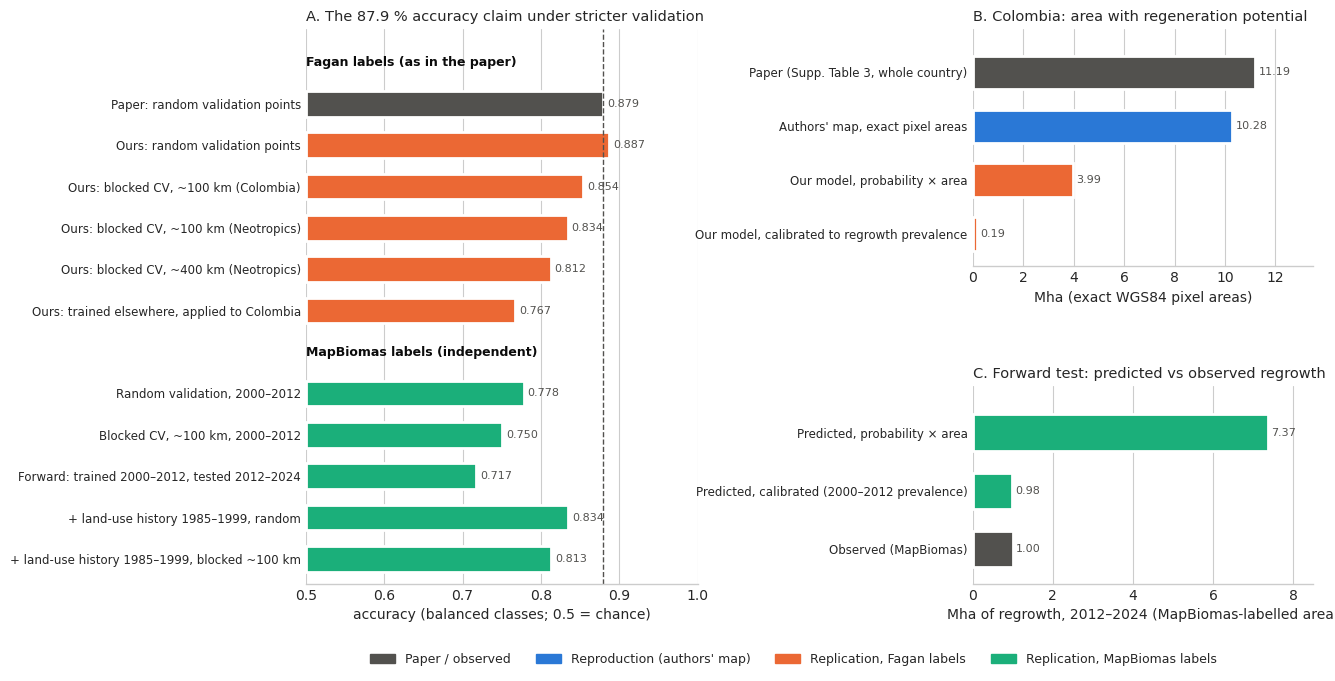

In [5]:
GREY, BLUE, ORANGE, AQUA, INK, INK2 = "#52514e", "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#52514e"
d3 = pd.read_csv(RESULTS / "diag3_transfer_colombia.csv").set_index("model")
tc = pd.read_csv(RESULTS / "diag3_transfer_curve.csv").set_index("scheme")
e2 = pd.read_csv(RESULTS / "mapbiomas_e2_forward.csv")
e3 = pd.read_csv(RESULTS / "mapbiomas_e3_history.csv")


def e2v(scope: str, metric: str) -> float:
    return float(e2[(e2.scope == scope) & (e2.metric == metric)].value.iloc[0])


def e3v(metric: str) -> float:
    return float(e3[e3.metric == metric].value.iloc[0])


acc_main = [
    ("Fagan labels (as in the paper)", None, None),
    ("Paper: random validation points", 0.879, GREY),
    ("Ours: random validation points", s2.loc["validation_accuracy", "value"], ORANGE),
    ("Ours: blocked CV, ~100 km (Colombia)", cv.loc["healpix_d6", "mean_accuracy"], ORANGE),
    ("Ours: blocked CV, ~100 km (Neotropics)", tc.loc["healpix_d6", "mean_accuracy"], ORANGE),
    ("Ours: blocked CV, ~400 km (Neotropics)", tc.loc["healpix_d4", "mean_accuracy"], ORANGE),
    ("Ours: trained elsewhere, applied to Colombia", d3.loc["neotropics_excl_colombia", "colombia_val_accuracy"], ORANGE),
    ("MapBiomas labels (independent)", None, None),
    ("Random validation, 2000–2012", e2v("period1_random_holdout", "balanced_accuracy"), AQUA),
    ("Blocked CV, ~100 km, 2000–2012", e2v("period1_cv", "cv_healpix_d6_balanced_accuracy"), AQUA),
    ("Forward: trained 2000–2012, tested 2012–2024", e2v("period2_forward_all", "balanced_accuracy"), AQUA),
    ("+ land-use history 1985–1999, random", e3v("validation_balanced_accuracy"), AQUA),
    ("+ land-use history 1985–1999, blocked ~100 km", e3v("cv_healpix_d6_balanced_accuracy"), AQUA),
]
area_main = [
    ("Paper (Supp. Table 3, whole country)", 11.19, GREY),
    ("Authors' map, exact pixel areas", s2.loc["authors_expected_in_pred_exact_mha", "value"], BLUE),
    ("Our model, probability × area", s2.loc["expected_area_uncalibrated_mha", "value"], ORANGE),
    ("Our model, calibrated to regrowth prevalence", s2.loc["expected_area_prior_shift_mha", "value"], ORANGE),
]
fw_main = [
    ("Predicted, probability × area", e2v("period2_forward_all", "predicted_regrowth_area_uncalibrated_mha"), AQUA),
    ("Predicted, calibrated (2000–2012 prevalence)", e2v("period2_forward_all", "predicted_regrowth_area_prior_shift_pi1_mha"), AQUA),
    ("Observed (MapBiomas)", e2v("period2_forward_all", "observed_regrowth_area_mha"), GREY),
]


def hbars(ax: plt.Axes, rows: list, fmt: str, xmax: float, xmin: float = 0.0) -> None:
    n = len(rows)
    for i, (lab, val, col) in enumerate(rows):
        yy = n - 1 - i
        if val is None:
            ax.text(xmin, yy, lab, fontsize=9, fontweight="bold", color=INK, va="center")
            continue
        ax.barh(yy, val - xmin, left=xmin, height=0.62, color=col, edgecolor="white", linewidth=2)
        ax.text(val + (xmax - xmin) * 0.01, yy, format(val, fmt), va="center", fontsize=8, color=INK2)
    ax.set_yticks(range(n), [("" if v is None else lab) for lab, v, _ in rows][::-1], fontsize=8.5)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-0.6, n - 0.2)
    ax.set_axisbelow(True)
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", length=0)
    for sp in ("top", "right", "left"):
        ax.spines[sp].set_visible(False)


fig = plt.figure(figsize=(13, 7.2))
gs = fig.add_gridspec(2, 2, width_ratios=[1.15, 1], height_ratios=[1.2, 1], wspace=0.75, hspace=0.55)
axA, axB, axC = fig.add_subplot(gs[:, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 1])
hbars(axA, acc_main, ".3f", 1.0, 0.5)
axA.axvline(0.879, color=GREY, ls="--", lw=1)
axA.set_xlabel("accuracy (balanced classes; 0.5 = chance)")
axA.set_title("A. The 87.9 % accuracy claim under stricter validation", loc="left", fontsize=10.5)
hbars(axB, area_main, ".2f", 13.5)
axB.set_xlabel("Mha (exact WGS84 pixel areas)")
axB.set_title("B. Colombia: area with regeneration potential", loc="left", fontsize=10.5)
hbars(axC, fw_main, ".2f", 8.5)
axC.set_xlabel("Mha of regrowth, 2012–2024 (MapBiomas-labelled area)")
axC.set_title("C. Forward test: predicted vs observed regrowth", loc="left", fontsize=10.5)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (GREY, BLUE, ORANGE, AQUA)]
fig.legend(handles, ["Paper / observed", "Reproduction (authors' map)", "Replication, Fagan labels",
                     "Replication, MapBiomas labels"], loc="lower center", ncol=4, frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.savefig(FIGURES / "main_result.png", dpi=150, bbox_inches="tight")
plt.show()